# 8 Logistic Regression
### LOGISTIC REGRESSION
By **Mohan Sirumalla**
***


## 1. Data Exploration

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Define ANSI codes for clarity
BOLD = '\033[1m'
END = '\033[0m' # Resets the format


In [28]:
df= pd.read_csv('08_B_diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [29]:
print(f"Dataset havning{BOLD} {df.shape[0]}{END} observation and {BOLD}{df.shape[1]}{END} variables")
# Print column names row by row
print(f"{BOLD}Feaures/Variables:{END}")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

Dataset havning 768 observation and 9 variables
Feaures/Variables:
1. Pregnancies
2. Glucose
3. BloodPressure
4. SkinThickness
5. Insulin
6. BMI
7. DiabetesPedigreeFunction
8. Age
9. Outcome


**Objective**\
The objective of the dataset is to diagnostically predict whether or not a patient has diabetes.

## 2. Data Preprocessing:

In [30]:
def show_missing_counts(dataframe,cat='null'):
    #Displays columns with null/zero values and their counts.
    print(f"{BOLD}Checking {cat} values.{END}...")
    if cat=='zero':
        missing_data = (df == 0).sum()
    else:
        missing_data = dataframe.isnull().sum()
        
    # Filter to show only columns with a count greater than 0
    missing_data = missing_data[missing_data > 0]
    if missing_data.empty:
        print(f"No columns have {cat} values.")
    else:
        print(f"Columns with {cat} values and their counts:")
        print(missing_data.sort_values(ascending=False)) # Sort in descending order


In [31]:
show_missing_counts(df,'null')
show_missing_counts(df,'zero')

Checking null values....
No columns have null values.
Checking zero values....
Columns with zero values and their counts:
Outcome          500
Insulin          374
SkinThickness    227
Pregnancies      111
BloodPressure     35
BMI               11
Glucose            5
dtype: int64


In [32]:
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)


In [33]:
df['Glucose'].isnull().sum()

np.int64(5)

In [34]:
show_missing_counts(df,'null')

Checking null values....
Columns with null values and their counts:
Insulin          374
SkinThickness    227
BloodPressure     35
BMI               11
Glucose            5
dtype: int64


In [35]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [36]:
def plot_data(data,chat_type,row,col,w,h):
    fig, axes = plt.subplots(row, col, figsize=(w, h))
    axes = axes.flatten()
    for i, column in enumerate(data.columns):
        if(chat_type=='Histogram'):
            axes[i].hist(data[column], bins=15,  edgecolor='black')
        elif (chat_type=='Boxplot'):
            axes[i].boxplot(data[column], patch_artist=True)
        elif (chat_type=='Bar'):
            df[column].value_counts().plot(kind='bar', ax=axes[i], rot=0)
        elif (chat_type=='Pie'):
            df[column].value_counts().plot(kind='pie', ax=axes[i],autopct='%1.1f%%')
        
        axes[i].set_title(f'{chat_type} of {column}')
        axes[i].set_xlabel(column)
        if(chat_type!='Pie'):
            axes[i].set_ylabel('Frequency')
        
    plt.tight_layout()
    plt.show()
             

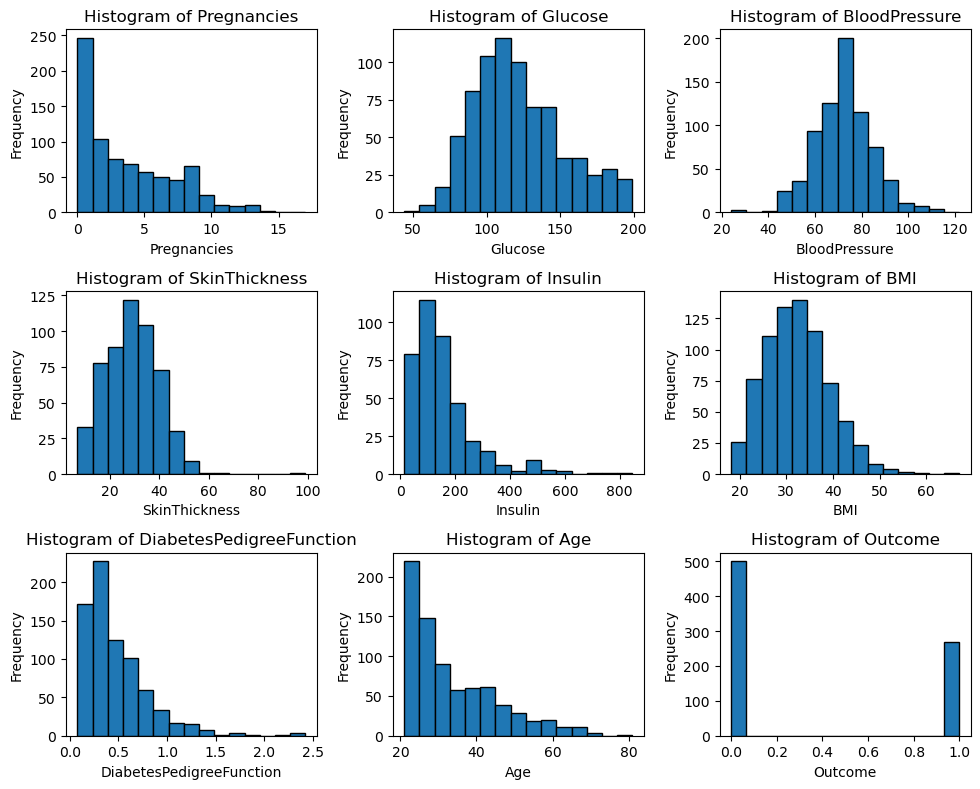

In [37]:
plot_data(df,'Histogram',3,3,10,8)

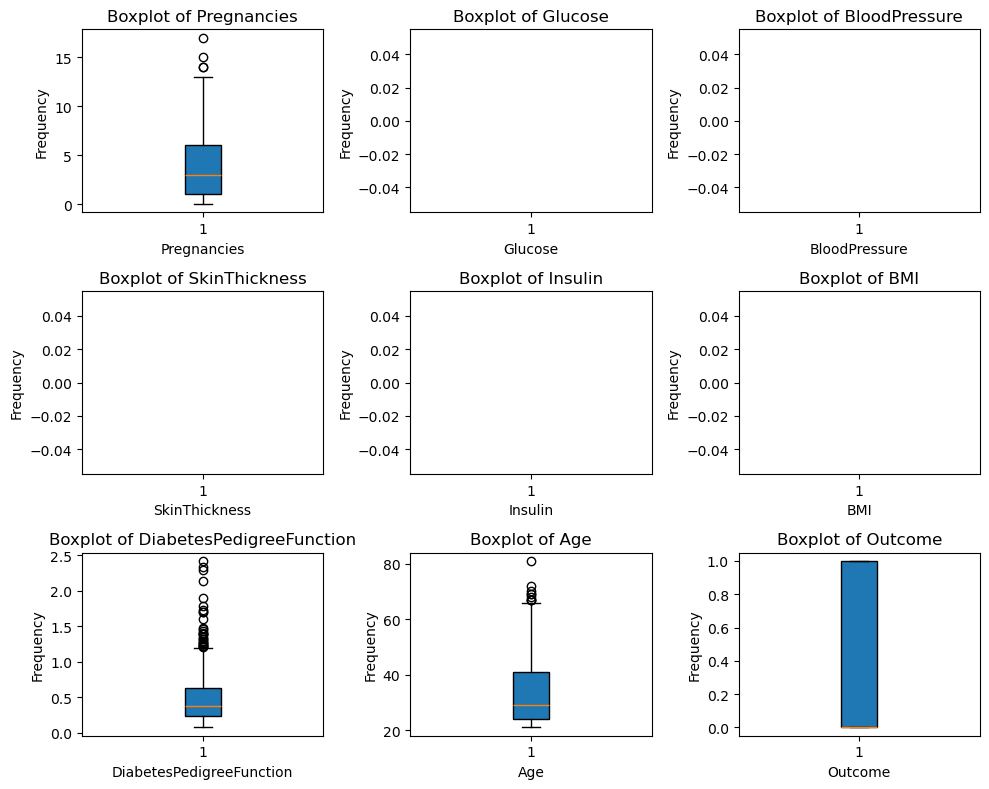

In [38]:
plot_data(df,'Boxplot',3,3,10,8)

In [39]:
df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)

In [40]:
show_missing_counts(df,'null')

Checking null values....
Columns with null values and their counts:
Insulin          374
SkinThickness    227
BloodPressure     35
BMI               11
Glucose            5
dtype: int64


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [42]:
df = df.fillna(df.median(numeric_only=True))

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [44]:
show_missing_counts(df,'zero')

Checking zero values....
Columns with zero values and their counts:
Outcome        500
Pregnancies    111
dtype: int64


In [45]:
df.groupby('Outcome').count() 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,500,500,500,500,500,500,500,500
1,268,268,268,268,268,268,268,268


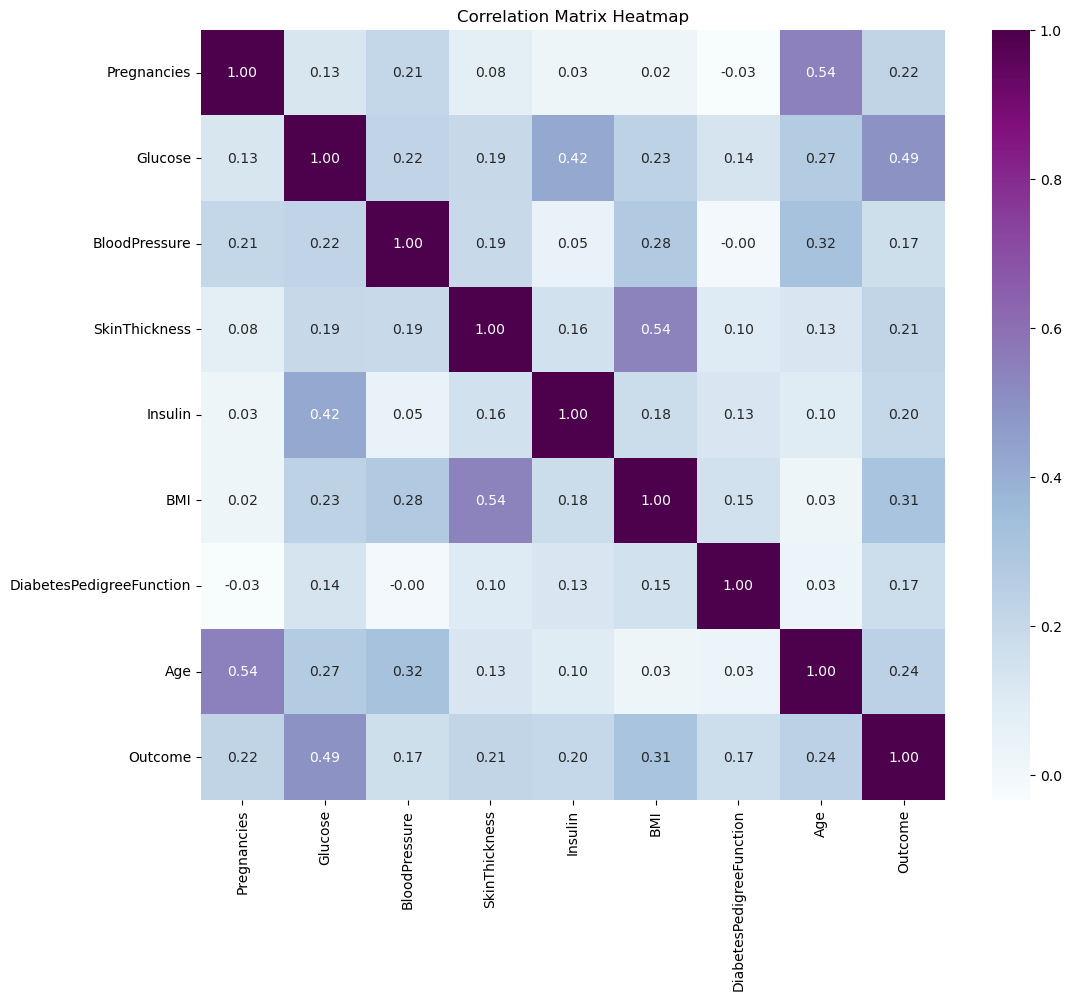

In [46]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='BuPu', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [47]:
df['Age'].describe()

count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64

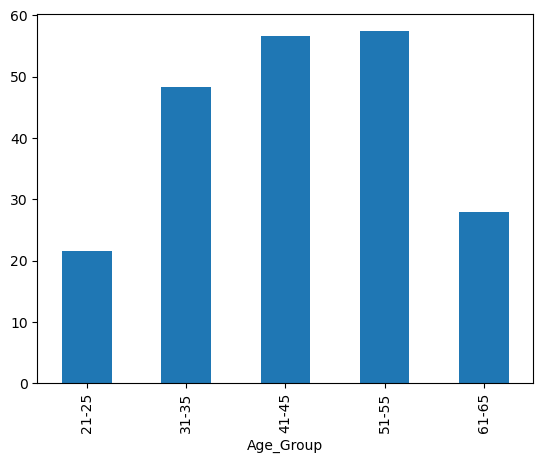

In [48]:

# Using [21, 26, 31, ..., 81] creates bins: 21-25, 26-30, etc.
bins = list(range(21, 82, 10)) 
# Add 86 to include 81 in the last range if desired, or adjust labels
labels = [f'{i}-{i+4}' for i in range(21, 81, 10)]

# Group by age range
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)


data1=df[df['Outcome']==1].groupby('Age_Group',observed=True)[['Outcome']].count()
data1
data1.head()

data2=df.groupby('Age_Group',observed=True)[['Outcome']].count()
data1['Diabetic %']=(data1['Outcome']/data2['Outcome'])*100
data1 = data1.sort_index()
data1['Diabetic %'].plot(kind='bar')
plt.show()


3. Model Building:

In [49]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Age_Group'],
      dtype='object')

In [50]:
from sklearn.model_selection import train_test_split

X = df.drop(['Outcome','Age_Group'], axis = 1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42, stratify = y)

In [51]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train =  pd.DataFrame(sc.fit_transform(X_train),
        columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age'])
X_test = pd.DataFrame(sc.fit_transform(X_test),
        columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age'])

In [52]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Age_Group'],
      dtype='object')

## 3. Model Building:

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score, auc

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

# 2. Train a model
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [54]:
# 3. Get predicted probabilities for the positive class
# We need probabilities, not just the final predicted class (0 or 1)
y_pred_proba = model.predict_proba(X_test)[:, 1]

## 4. Model Evaluation:

ROC AUC Score: 0.815


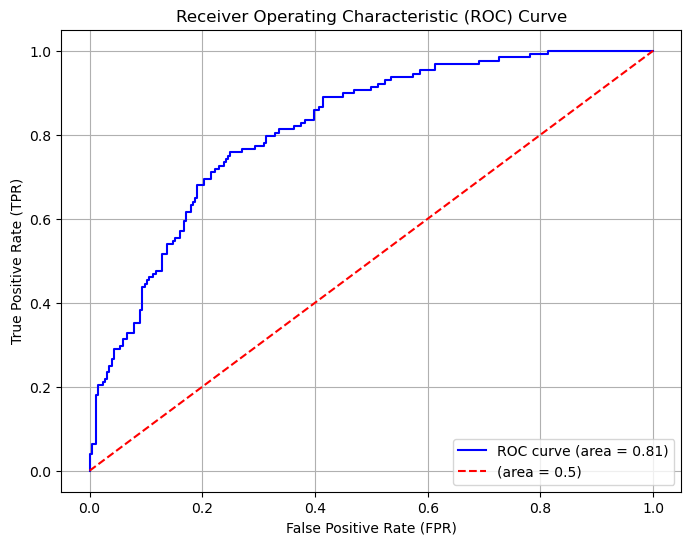

In [55]:

# 4. Calculate the ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC AUC Score: {roc_auc:.3f}')

# 5. Calculate ROC curve values (FPR, TPR, thresholds)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 6. Visualize the ROC curve
plt.figure(figsize=(8, 6))
# Plot the ROC curve
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % roc_auc)
# Plot the "No Skill" line (random guessing)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='(area = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 5. Interpretation:

### Interpret the coefficients of the logistic regression model

In [56]:
 model.coef_

array([[ 0.20919558,  0.0430621 , -0.01927804,  0.00975449, -0.00244691,
         0.09039991,  0.78904184,  0.00881747]])

In [57]:
model.intercept_

array([-9.06665435])

In [58]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Age_Group'],
      dtype='object')

### Siginficance of features in predicting the target variable

##### The prediction of survival probability in diabetes patients is a complex task that relies on analyzing both demographic and clinical features to determine the risk of mortality or severe complications. Machine learning (ML) models, particularly ensemble methods like Random Forest and XGBoost, are highly effective, achieving accuracies often exceeding 90% in predicting diabetes risk, with feature importance analyses identifying critical, actionable factors

**Key features influencing the prediction of diabetes survival and mortality include:**\

**Glucose Levels (HbA1c & Fasting Plasma Glucose):** Frequently identified as the most significant feature, hemoglobin A1c (HbA1c) reflects average blood glucose over months and is crucial for predicting diabetes progression and mortality. High HbA1c is strongly associated with higher all-cause mortality.\
**Kidney Function Markers:** A lower estimated glomerular filtration rate (eGFR) is one of the strongest predictors of higher mortality in diabetic patients. Impaired renal function significantly increases long-term mortality.\
**Body Mass Index (BMI):** While obesity is a key risk factor for developing diabetes, studies show a "paradox" in mortality prediction where lower BMI (<25 kg/m²) in diabetics can be associated with higher mortality risk compared to slightly higher BMIs.\
**Age:** Advancing age is a significant, non-modifiable predictor of higher mortality in patients with diabetes.\
**Comorbidities (Hypertension & Cardiovascular Disease):** The presence of macrovascular diseases (e.g., heart attack, stroke) and hypertension is a primary predictor of cardiovascular mortality.\
**Duration of Diabetes:** A longer duration of diabetes (e.g., $\ge$9 years) significantly increases the hazard ratio for all-cause mortality.\
**Lifestyle and Socioeconomic Factors:** Smoking and lower income/education levels are independent predictors of higher mortality risk\

## 6. Deployment with Streamlit

In this task, you will deploy your logistic regression model using Stremlit. The deployment can be done locally or online via Streamlit Share. Your task includes creating a Stramlit app in Pyton that invlovles loading your trained model and setting up user inputs for predictions

## Model Saving to file

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score, auc

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

# 2. Train a model
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### Pickle

**In machine learning,**\
**Pickle** is the standard Python module used for **serializing** (saving) and **deserializing** (loading) trained models and other Python objects to and from a binary file format.\
This process allows developers to save the state of a model after a time-consuming training process and reuse it later to make predictions without having to retrain it from scratch.

In [41]:
import pickle

filename = 'MohanSirumalla_Log_Reg_diabetes.pkl' 

# Open the file in write-binary mode and save the model
with open(filename, 'wb') as file:
    pickle.dump(model, file)
   

Streamlit
is an open-source Python library to create and share interactive, custom web applications using only Python,

Create a Python File for Streamlit

## Interview Questions:

1. What is the difference between precision and recall?

**Precision** measures how accurate positive predictions are (avoiding false alarms), while \
**Recall** measures how well the model finds all actual positives (avoiding missing cases).\
Precision is $TP/(TP + FP)$ \
and\
recall is $TP / (TP + FN)$. \
In short, precision asks, "Of all predicted positives, how many are real?", while recall asks, "Of all actual positives, how many did I find?"\


**Simple Example: Identifying Spam Emails**\
Imagine you have 100 total emails, 10 of which are actually spam (Actual Positives).
Your model identifies 8 emails as spam (Predicted Positives). 

Scenario A: Of those 8 identified emails, 7 are actually spam, and 1 is legitimate.\
        Precision:7/8=87.5%(High accuracy in predictions).\
        Recall:7/10=70%(Missed 3 spam emails).\
    Scenario B (Lowering threshold to catch more): \
    Your model identifies 15 emails as spam, including all 10 real ones (but 5 are actually safe).\
        Precision:10/15=66.67%(More false alarms).\
        Recall:10/10=100% (Caught all spam). 

**Key Differences**\
Precision $TP/(TP + FP)$ : High precision is crucial when false positives are costly (e.g., classifying safe emails as spam).\
Recall $TP / (TP + FN)$.: High recall is crucial when false negatives are dangerous (e.g., missing a cancer diagnosis).\
Trade-off: Increasing recall often lowers precision, and vice-versa.

2. What is cross-validation and why is it important in binary classification

Cross-validation is a robust, iterative statistical technique used to evaluate machine learning models by partitioning data into multiple subsets (folds), training on some, and validating on others.\
In binary classification, it is critical for ensuring reliable performance estimates, preventing overfitting, and handling imbalanced datasets by validating against unseen data

**Key Aspects and Importance:**

* **Preventing Overfitting:** It ensures the model generalizes well to new data rather than just memorizing training data.
* **Reliable Performance Estimation:** By averaging metrics (like accuracy, precision, or recall) over several rounds, it reduces variance in performance metrics.\
* **Stratified K-Fold for Classification:** Specifically in binary classification, stratified cross-validation is used to maintain the percentage of samples for each class in every fold, ensuring both classes are adequately represented during training and testing.
* **Model Tuning:** It is essential for selecting optimal hyperparameters without leaking information from the test set.
* **Maximized Data Usage:** Every data point is used for both training and validation, which is particularly valuable for small datasets

**How it Works (K-Fold Example):**

* Divide the dataset into **K** equal-sized segments (folds).
* Train the model on **K-1** folds and test on the remaining fold.
* Repeat this process **K** times, using a different fold for testing each time.
* Average the results from all **K**  trials. 

Common techniques include K-Fold, Stratified K-Fold (best for imbalanced binary classes), and Leave-One-Out cross-validation.

##  Resubmit of Logistic Regression

### Missing Values

In [22]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Define ANSI codes for clarity
BOLD = '\033[1m'
END = '\033[0m' # Resets the format
# Read Data
df= pd.read_csv('08_B_diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [25]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### Check Duplicate Records

In [23]:
# Check Duplicate Records if any
if not df.duplicated().any():
    print("No Duplicates")
else:
    print("Duplicate records")

No Duplicates


#### Check Null Values

In [24]:
#check for missing values, count them and print the sum for every column
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#### Check Zero Value

In [14]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

**As Per df.describe() having Min Zero values**

In [26]:
print(f"{BOLD}Zero Values Count{END}")
print(f"Pregnancies : {df[df['Pregnancies']==0].shape[0]} observations") # can be zero
print(f"BloodPressure : {df[df['BloodPressure']==0].shape[0]} observations")
print(f"Glucose :{df[df['Glucose']==0].shape[0]} observations")
print(f"SkinThickness :{df[df['SkinThickness']==0].shape[0]} observations")
print(f"Insulin :{df[df['Insulin']==0].shape[0]} observations")
print(f"BMI :{df[df['BMI']==0].shape[0]} observations")


Zero Values Count
Pregnancies : 111 observations
BloodPressure : 35 observations
Glucose :5 observations
SkinThickness :227 observations
Insulin :374 observations
BMI :11 observations


**Analysis of 0 Values:**
* Pregnancies: 0 is valid (indicates no pregnancies).
* Glucose: 0 is invalid (a living person cannot have zero blood glucose).
* BloodPressure: 0 is invalid.
* SkinThickness: 0 is invalid (biologically impossible).
* Insulin: 0 is invalid (many entries are 0, but it is impossible in this context).
* BMI: 0 is invalid.

**Zero Values need to be replaced with appropriate values in case of Glucose,BloodPressure,SkinThickness,Insulin,Insulin**

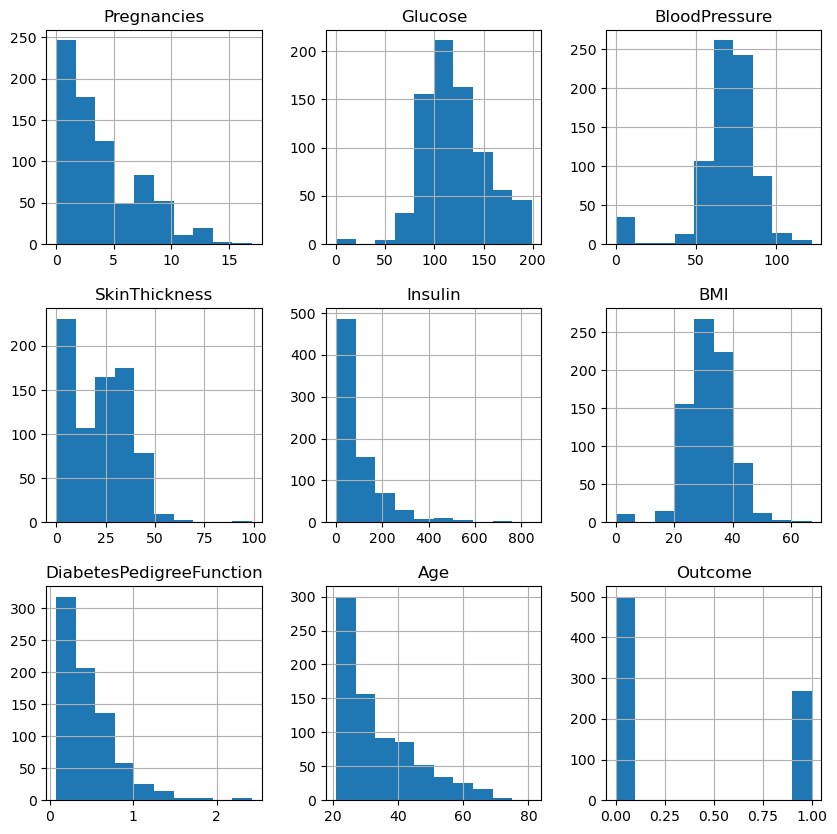

In [28]:
#histogram for each  feature
df.hist(bins=10,figsize=(10,10))
plt.show()

**As per above Histogram Glucose,BloodPressure are following normal distribution So we can replace 0 with Mean**\
**As per above Histogram SkinThickness, Insulin,BMI having skewed distributions, so we can replace 0 with Median**

In [31]:
#replacing 0 values with mean
df['Glucose']=df['Glucose'].replace(0,df['Glucose'].mean())
df['BloodPressure']=df['BloodPressure'].replace(0,df['BloodPressure'].mean())
#replacing 0 values with median
df['SkinThickness']=df['SkinThickness'].replace(0,df['SkinThickness'].median())
df['Insulin']=df['Insulin'].replace(0,df['Insulin'].median())
df['BMI']=df['BMI'].replace(0,df['BMI'].median())

In [32]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.681605,72.254807,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.436016,12.115932,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### PairPlot Visualization

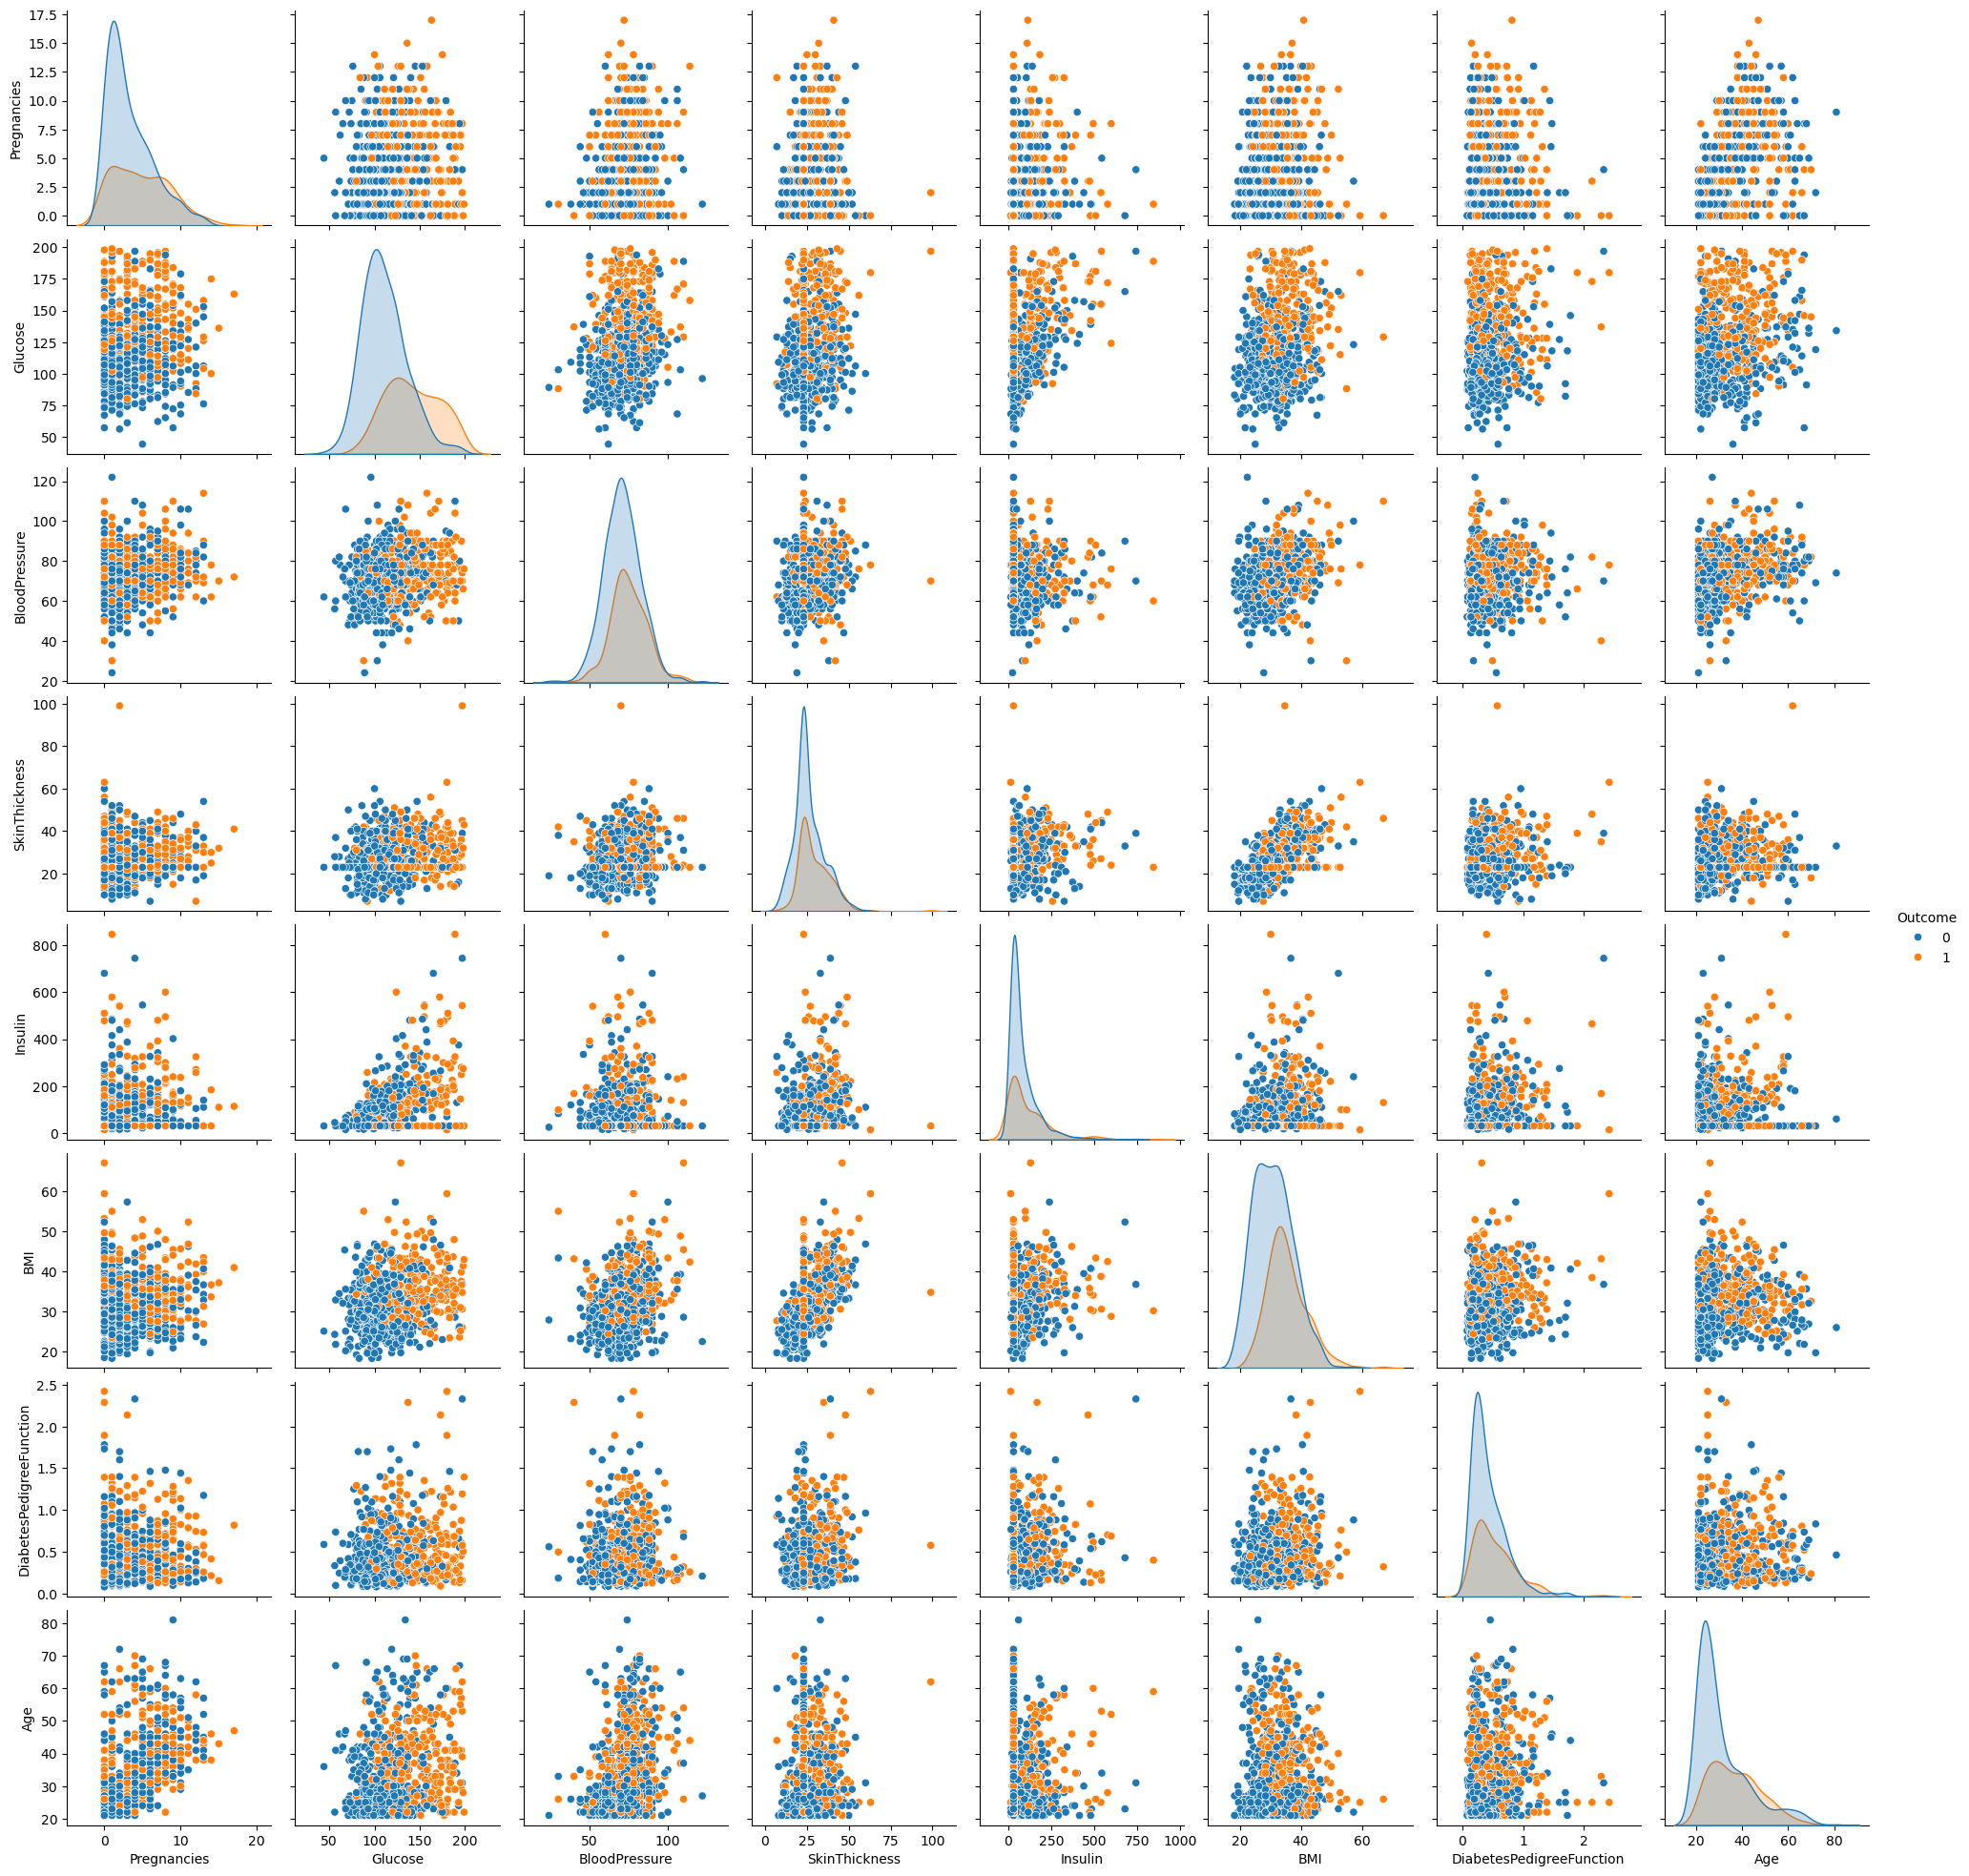

In [34]:
# Visualizing the relationships with a pairplot, colored by Outcome
sns.pairplot(df, hue='Outcome', vars=['Pregnancies', 'Glucose', 'BloodPressure', 
                                      'SkinThickness', 'Insulin', 'BMI', 
                                      'DiabetesPedigreeFunction', 'Age'])
plt.show()

### Streamlit deployment

#### Create Model

In [59]:
#Create Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score, auc

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

# 2. Train a model
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

#### Pickle is the standard Python module used for serializing (saving) and deserializing (loading) trained models

In [ ]:
# Model Saving to file

In [60]:
import pickle

filename = 'MohanSirumalla_diabetes.pkl' 

# Open the file in write-binary mode and save the model
with open(filename, 'wb') as file:
    pickle.dump(model, file)

**Create a Python File for Streamlit**

**Created app.py python file will above content**\
From the command prompt we can run the following commant to run Streamlit\
**streamlit run app.py**

Deployment done on Streamlit and Files stored on Gitbub
https://mohansirumalla.streamlit.app/
https://github.com/sirumallamohan-max/streamlit


[Click Here to see the deployment](https://mohansirumalla.streamlit.app)

In [69]:
from IPython.display import display, HTML
display(HTML("""<a href="https://mohansirumalla.streamlit.app/">Click Here to Open the deployment</a>"""))